In [4]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph

In [5]:
## Recipe Formatter

class RecipeState(TypedDict):
    ingredients: list[str]
    instructions: list[str]
    formatted_ingredients: list[str]
    formatted_instructions: list[str]
    is_valid: bool
    final_recipe: str

In [15]:
def format_ingredients(state: RecipeState) -> dict:
    formatted = [f". {ingredient.upper()} " for ingredient in state['ingredients']]
    return {"formatted_ingredients": formatted}

def format_instructions(state: RecipeState) -> dict:
    formatted = [f"{i+1}. {instruction}" for i, instruction in enumerate(state['instructions'])]
    return {"formatted_instructions": formatted}

def validate_recipe(state: RecipeState) -> bool:
    is_valid = len(state["ingredients"]) > 0 and len(state["instructions"]) > 0
    return {"is_valid": is_valid}

def final_recipe(state: RecipeState) -> dict:
    if state["is_valid"]:
        final= f"INGREDIENTS: \n{state['formatted_ingredients']}\n\nINSTRUCTIONS: \n{state['formatted_instructions']}"
    else:
        final = "Invalid recipe: no ingredients or instructions provided."
    return {"final_recipe": final}

In [16]:
# Sequential Workflow

graph = StateGraph(RecipeState)

# Add nodes
graph.add_node("format_ingredients", format_ingredients)
graph.add_node("format_instructions", format_instructions)
graph.add_node("validate_recipe", validate_recipe)
graph.add_node("final_recipe", final_recipe)

# Add edges
graph.add_edge(START, "format_ingredients")
graph.add_edge("format_ingredients", "format_instructions")
graph.add_edge("format_instructions", "validate_recipe")
graph.add_edge("validate_recipe", "final_recipe")
graph.add_edge("final_recipe", END)

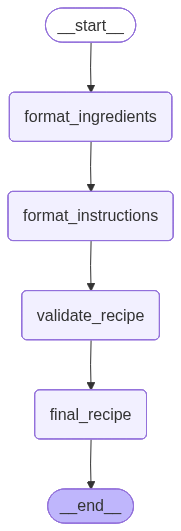

In [18]:
app = graph.compile()
app

In [19]:
# Test data
test_recipe = {
    "ingredients": ["flour", "eggs", "milk", "butter"],
    "instructions": [
        "Mix flour and eggs",
        "Add milk gradually",
        "Melt butter and fold in"
    ],
    "formatted_ingredients": "",
    "formatted_instructions": "",
    "is_valid": False,
    "final_recipe": ""
}

# Test app:
result = app.invoke(test_recipe)
print(result['final_recipe'])

INGREDIENTS: 
['. FLOUR ', '. EGGS ', '. MILK ', '. BUTTER ']

INSTRUCTIONS: 
['1. Mix flour and eggs', '2. Add milk gradually', '3. Melt butter and fold in']
